In [9]:
%pip install hmmlearn tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import polars as pl

parquet_path = r"C:\Users\wongb\Downloads\ratings-20260117-20260217.parquet"
df = pl.read_parquet(parquet_path)
df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification
i64,i64,str,str,datetime[ms],datetime[ms],datetime[ms],str,bool
1357294499052085249,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""FB8A5B50F04AAB7CCEA99B4094EAA1…",2021-02-04 10:08:21.128,2021-02-04 11:46:40.544,2026-02-01 14:36:13.314,"""NOT_HELPFUL""",false
1357297935407603713,1357269755112148993,"""FE4BA8F630E66459C9F2EEBDDF69C4…","""B9BEE8138A8A67538391BC79C1E9DF…",2021-02-04 10:08:21.128,2021-02-04 12:00:19.835,2026-02-01 14:36:04.345,"""NOT_HELPFUL""",false
1358604958673719296,1358464064322691078,"""456D1C422BA1A09690B986C8A1DBE7…","""FAB1117EE31D648BA7C11062F626AF…",2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 08:56:34.712,"""NOT_HELPFUL""",false
1358604958673719296,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""FAB1117EE31D648BA7C11062F626AF…",2021-02-07 17:14:06.633,2021-02-08 02:33:58.465,2026-02-09 00:51:34.502,"""NOT_HELPFUL""",false
1358844963216326659,1358464064322691078,"""4B3821FC937ACD882F8BD4045DD281…","""605A405C64CC57A943D086CC80E5AC…",2021-02-07 17:14:06.633,2021-02-08 18:27:40.007,2026-02-09 00:51:18.076,"""NOT_HELPFUL""",false
…,…,…,…,…,…,…,…,…
1873623034814238798,1873417011294093499,"""C6C2E0DD1A03ADE2BC4C0F1870E01E…","""27AC2BCC9AF39C20C5ECC5D5A45F32…",2024-12-29 17:13:16.554,2024-12-30 06:51:56.390,2026-02-14 01:57:17.194,"""HELPFUL""",false
1873640928910692708,1873299604080607330,"""E26C94838DB911EDA747183982B930…","""7F16863BE3FB87264952B6B64F8082…",2024-12-29 09:26:44.493,2024-12-30 08:03:02.674,2026-02-14 20:22:12.656,"""NOT_HELPFUL""",false
1873642906235351150,1873299604080607330,"""E26C94838DB911EDA747183982B930…","""BE38D44A6D5F6828EE25798913696D…",2024-12-29 09:26:44.493,2024-12-30 08:10:54.106,2026-02-14 20:22:02.614,"""NOT_HELPFUL""",false


In [34]:
ratings_preprocessed_df = (
    df
    .with_columns(
        pl.col("ratingCreatedAt")
        .cast(pl.Datetime, strict=False)
        .alias("ratingCreatedAt_ts")
    )
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .with_columns(
        pl.col("ratingCreatedAt_ts")
        .diff()
        .over("raterParticipantId")
        .dt.total_seconds()
        .alias("delta_seconds")
    )
    .with_columns(
        pl.when(pl.col("delta_seconds") > 0)
        .then(pl.col("delta_seconds").log())
        .otherwise(None)
        .alias("log_delta_seconds")
    )
)

ratings_preprocessed_df

noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds
i64,i64,str,str,datetime[ms],datetime[ms],datetime[ms],str,bool,datetime[μs],i64,f64
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…",2026-01-27 20:27:38.894,2026-01-28 15:31:55.816,2026-01-28 20:47:22.321,"""HELPFUL""",false,2026-01-28 20:47:22.321,null,null
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…",2026-01-31 12:40:49.235,2026-01-31 16:48:49.996,2026-01-31 17:21:23.365,"""HELPFUL""",false,2026-01-31 17:21:23.365,246841,12.4165
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…",2026-02-02 18:15:48.768,2026-02-02 19:20:41.831,2026-02-02 22:44:01.605,"""HELPFUL""",false,2026-02-02 22:44:01.605,192158,12.166073
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…",2026-01-17 18:02:30.876,2026-01-17 22:10:32.357,2026-01-18 15:41:27.835,"""NOT_HELPFUL""",false,2026-01-18 15:41:27.835,null,null
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…",2026-01-17 18:02:30.876,2026-01-18 01:08:02.720,2026-01-18 15:44:04.360,"""HELPFUL""",false,2026-01-18 15:44:04.360,156,5.049856
…,…,…,…,…,…,…,…,…,…,…,…
2020752418963669036,2020604630657302841,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""BA48B1306E38D71468370309229E18…",2026-02-08 21:04:19.624,2026-02-09 06:51:35.102,2026-02-09 08:02:06.384,"""NOT_HELPFUL""",false,2026-02-09 08:02:06.384,1041422,13.856098
2021916824426701208,2021784932818067904,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""E6ABEA01CD00795F7897A1245141FF…",2026-02-12 03:14:25.588,2026-02-12 11:58:30.999,2026-02-12 15:50:43.969,"""HELPFUL""",false,2026-02-12 15:50:43.969,287317,12.568341
2019488960465031197,2019467286298472468,"""FFFFC46B8555A97065DB39F7D600C8…","""8D8A300EC055D96FC685C886688785…",2026-02-05 17:44:55.598,2026-02-05 19:11:03.122,2026-02-06 08:34:11.398,"""HELPFUL""",false,2026-02-06 08:34:11.398,null,null


In [35]:
ratings_per_user = (
    ratings_preprocessed_df
    .group_by("raterParticipantId")
    .agg(pl.len().alias("ratings_count"))
)

summary_stats_df = ratings_preprocessed_df.select(
    pl.len().alias("total_ratings"),
    pl.col("raterParticipantId").n_unique().alias("total_users"),
    pl.lit(ratings_per_user["ratings_count"].mean()).alias("avg_ratings_per_user"),
    pl.col("delta_seconds").mean().alias("avg_time_gap_seconds"),
    pl.col("delta_seconds").median().alias("median_time_gap_seconds"),
    pl.col("log_delta_seconds").mean().alias("avg_log_time_gap"),
    pl.col("log_delta_seconds").median().alias("median_log_time_gap"),
)

summary_stats_df

total_ratings,total_users,avg_ratings_per_user,avg_time_gap_seconds,median_time_gap_seconds,avg_log_time_gap,median_log_time_gap
u32,u32,f64,f64,f64,f64,f64
6499635,484059,13.427361,83461.493586,2012.0,7.165669,7.607878


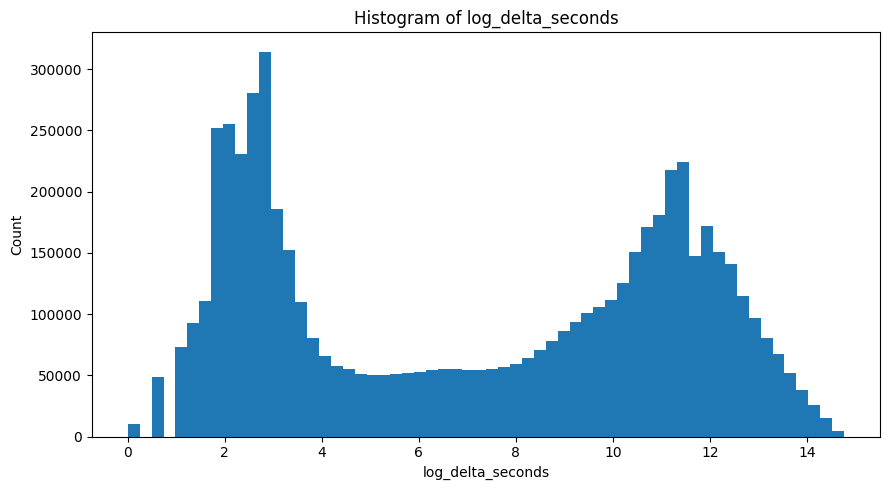

In [36]:
import matplotlib.pyplot as plt

if "ratings_preprocessed_df" not in globals():
    raise ValueError("`ratings_preprocessed_df` not found. Run Cell 3 first.")

values = (
    ratings_preprocessed_df
    .select("log_delta_seconds")
    .drop_nulls()
    .to_series()
    .to_numpy()
 )

plt.figure(figsize=(9, 5))
plt.hist(values, bins=60)
plt.title("Histogram of log_delta_seconds")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import polars as pl
from hmmlearn.hmm import GaussianHMM
from tqdm.auto import tqdm

# -----------------------------
# Run configuration (edit these)
# -----------------------------
SAMPLE_MODE = False
SAMPLE_RATERS = 100000
RANDOM_SEED = 42
HMM_MAX_ITER = 50

if "ratings_preprocessed_df" not in globals():
    if "df" not in globals():
        raise ValueError("`df` not found. Run Cell 2 first to load your parquet data.")

    ratings_preprocessed_df = (
        df
        .with_columns(
            pl.col("ratingCreatedAt")
            .cast(pl.Datetime, strict=False)
            .alias("ratingCreatedAt_ts")
        )
        .sort(["raterParticipantId", "ratingCreatedAt_ts"])
        .with_columns(
            pl.col("ratingCreatedAt_ts")
            .diff()
            .over("raterParticipantId")
            .dt.total_seconds()
            .alias("delta_seconds")
        )
        .with_columns(
            pl.when(pl.col("delta_seconds") > 0)
            .then(pl.col("delta_seconds").log())
            .otherwise(None)
            .alias("log_delta_seconds")
        )
    )

progress = tqdm(total=7, desc="Session labeling", unit="step")

working_df = ratings_preprocessed_df
progress.set_postfix_str("choose data scope")

if SAMPLE_MODE:
    unique_raters_df = working_df.select("raterParticipantId").unique()
    total_raters = unique_raters_df.height
    n_sample = min(SAMPLE_RATERS, total_raters)
    sampled_raters = unique_raters_df.sample(
        n=n_sample, seed=RANDOM_SEED, shuffle=True
    )["raterParticipantId"].to_list()
    working_df = working_df.filter(pl.col("raterParticipantId").is_in(sampled_raters))
    print(f"SAMPLE_MODE=True -> using {n_sample} raters out of {total_raters}")
else:
    print("SAMPLE_MODE=False -> using all raters")
progress.update(1)

progress.set_postfix_str("sort + row index")
hmm_input_df = (
    working_df
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .with_row_index("row_nr")
)
progress.update(1)

progress.set_postfix_str("build observations")
valid_obs_df = hmm_input_df.filter(pl.col("log_delta_seconds").is_not_null())
if valid_obs_df.height == 0:
    raise ValueError("No valid non-null log_delta_seconds observations found.")

X = valid_obs_df["log_delta_seconds"].to_numpy().reshape(-1, 1)
progress.update(1)

progress.set_postfix_str("compute sequence lengths")
lengths = (
    valid_obs_df
    .group_by("raterParticipantId", maintain_order=True)
    .agg(pl.len().alias("n"))["n"]
    .to_list()
)
if len(lengths) == 0:
    raise ValueError("No user sequences found for HMM fitting.")
progress.update(1)

progress.set_postfix_str("fit HMM")
hmm = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=HMM_MAX_ITER,
    random_state=RANDOM_SEED,
)
hmm.fit(X, lengths=lengths)
progress.update(1)

progress.set_postfix_str("decode states")
decoded_states = hmm.predict(X, lengths=lengths)
state_means = hmm.means_.flatten()
in_session_state = int(np.argmin(state_means))
in_session_binary = (decoded_states == in_session_state).astype(np.int8)
progress.update(1)

progress.set_postfix_str("map to events")
state_df = pl.DataFrame({
    "row_nr": valid_obs_df["row_nr"],
    "in_session_prev_gap": in_session_binary,
})

ratings_session_df = (
    hmm_input_df
    .join(state_df, on="row_nr", how="left")

    # Step 1: promote session-starters
    # A rating with a large gap (null or 0) should be in_session=1
    # if the NEXT rating has a small gap (in_session_prev_gap=1),
    # meaning this rating started a session that continued
    .with_columns(
        pl.col("in_session_prev_gap")
        .shift(-1)
        .over("raterParticipantId")
        .alias("next_gap_in_session")
    )
    .with_columns(
        pl.when(
            (pl.col("in_session_prev_gap") == 1) |  # continuation: small gap back
            (pl.col("next_gap_in_session") == 1)     # session-starter: small gap forward
        )
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .cast(pl.Int8)
        .alias("in_session")
    )

    # Step 2: remove singletons
    # A rating is truly isolated if both neighbors are 0 — not a real session
    .with_columns([
        pl.col("in_session").shift(1).over("raterParticipantId").fill_null(0).alias("prev_in_session"),
        pl.col("in_session").shift(-1).over("raterParticipantId").fill_null(0).alias("next_in_session"),
    ])
    .with_columns(
        pl.when(
            (pl.col("in_session") == 1) &
            (pl.col("prev_in_session") == 0) &
            (pl.col("next_in_session") == 0)
        )
        .then(pl.lit(0))
        .otherwise(pl.col("in_session"))
        .cast(pl.Int8)
        .alias("in_session")
    )
    .drop(["row_nr", "in_session_prev_gap", "next_gap_in_session", "prev_in_session", "next_in_session"])
)
progress.update(1)
progress.close()

print("HMM state means:", state_means)
print("In-session state index:", in_session_state)

ratings_session_df

Session labeling:   0%|          | 0/7 [00:00<?, ?step/s]

SAMPLE_MODE=False -> using all raters
HMM state means: [ 2.6606704  10.25462549]
In-session state index: 0


noteId,ratedOnTweetId,raterParticipantId,noteAuthorParticipantId,postCreatedAt,noteCreatedAt,ratingCreatedAt,helpfulnessLevel,fromNotification,ratingCreatedAt_ts,delta_seconds,log_delta_seconds,in_session
i64,i64,str,str,datetime[ms],datetime[ms],datetime[ms],str,bool,datetime[μs],i64,f64,i8
2016534713742061788,2016246745739546987,"""00002C7FD6E0080A69D0AB879C3D9B…","""FD7979DE7F187DC14A4FDF8F557242…",2026-01-27 20:27:38.894,2026-01-28 15:31:55.816,2026-01-28 20:47:22.321,"""HELPFUL""",false,2026-01-28 20:47:22.321,null,null,0
2017641230612451495,2017578816177111423,"""00002C7FD6E0080A69D0AB879C3D9B…","""2CE75633DDBFF074EE77E7DC582D7B…",2026-01-31 12:40:49.235,2026-01-31 16:48:49.996,2026-01-31 17:21:23.365,"""HELPFUL""",false,2026-01-31 17:21:23.365,246841,12.4165,0
2018404224149717157,2018387895459983768,"""00002C7FD6E0080A69D0AB879C3D9B…","""54F0002E8A4890D64140C45F5D108C…",2026-02-02 18:15:48.768,2026-02-02 19:20:41.831,2026-02-02 22:44:01.605,"""HELPFUL""",false,2026-02-02 22:44:01.605,192158,12.166073,0
2012648760455671942,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""B5A7C39C8965D9D8AF5CC38B994AAC…",2026-01-17 18:02:30.876,2026-01-17 22:10:32.357,2026-01-18 15:41:27.835,"""NOT_HELPFUL""",false,2026-01-18 15:41:27.835,null,null,0
2012693431319990371,2012586343008755726,"""00003D7D222733AE9D37A25B930204…","""D174DF64F45A03029780F273B4335C…",2026-01-17 18:02:30.876,2026-01-18 01:08:02.720,2026-01-18 15:44:04.360,"""HELPFUL""",false,2026-01-18 15:44:04.360,156,5.049856,0
…,…,…,…,…,…,…,…,…,…,…,…,…
2020752418963669036,2020604630657302841,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""BA48B1306E38D71468370309229E18…",2026-02-08 21:04:19.624,2026-02-09 06:51:35.102,2026-02-09 08:02:06.384,"""NOT_HELPFUL""",false,2026-02-09 08:02:06.384,1041422,13.856098,0
2021916824426701208,2021784932818067904,"""FFFFBBAB3C66ABB4DBC2A3B486C3C6…","""E6ABEA01CD00795F7897A1245141FF…",2026-02-12 03:14:25.588,2026-02-12 11:58:30.999,2026-02-12 15:50:43.969,"""HELPFUL""",false,2026-02-12 15:50:43.969,287317,12.568341,0
2019488960465031197,2019467286298472468,"""FFFFC46B8555A97065DB39F7D600C8…","""8D8A300EC055D96FC685C886688785…",2026-02-05 17:44:55.598,2026-02-05 19:11:03.122,2026-02-06 08:34:11.398,"""HELPFUL""",false,2026-02-06 08:34:11.398,null,null,0


In [38]:
ratings_session_df.write_csv("C:\\Users\\wongb\\user_trajectories_winter\\494-user-trajectories\\students\\benedict\\data\\behavior\\HMM_raw.csv")

In [39]:
if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run Cell 5 first.")

import polars as pl

# 1) Overall label distribution
label_counts_df = (
    ratings_session_df
    .group_by("in_session")
    .agg(pl.len().alias("n"))
    .sort("in_session")
)

total_rows = ratings_session_df.height
in_session_rows = label_counts_df.filter(pl.col("in_session") == 1).select(pl.col("n").sum()).item() or 0
in_session_rate = in_session_rows / total_rows if total_rows else 0.0

# 2) Per-user stats
per_user_df = (
    ratings_session_df
    .group_by("raterParticipantId")
    .agg(
        pl.len().alias("n_events"),
        pl.col("in_session").sum().alias("n_in_session"),
    )
    .with_columns(
        (pl.col("n_in_session") / pl.col("n_events")).alias("in_session_rate"),
        (pl.col("n_in_session") > 0).cast(pl.Int8).alias("has_any_in_session"),
        (pl.col("n_in_session") == pl.col("n_events")).cast(pl.Int8).alias("all_events_in_session"),
    )
    .sort("n_events", descending=True)
)

n_users = per_user_df.height
n_users_any_in = per_user_df.filter(pl.col("has_any_in_session") == 1).height
n_users_none_in = per_user_df.filter(pl.col("has_any_in_session") == 0).height
n_users_all_in = per_user_df.filter(pl.col("all_events_in_session") == 1).height

avg_user_in_rate = per_user_df.select(pl.col("in_session_rate").mean()).item()
median_user_in_rate = per_user_df.select(pl.col("in_session_rate").median()).item()

user_rate_quantiles_df = per_user_df.select(
    pl.col("in_session_rate").quantile(0.10).alias("p10"),
    pl.col("in_session_rate").quantile(0.25).alias("p25"),
    pl.col("in_session_rate").quantile(0.50).alias("p50"),
    pl.col("in_session_rate").quantile(0.75).alias("p75"),
    pl.col("in_session_rate").quantile(0.90).alias("p90"),
)

user_mix_summary_df = pl.DataFrame(
    {
        "metric": [
            "n_users",
            "n_users_any_in_session",
            "n_users_no_in_session",
            "n_users_all_in_session",
            "share_users_any_in_session",
            "share_users_no_in_session",
            "share_users_all_in_session",
            "avg_user_in_session_rate",
            "median_user_in_session_rate",
        ],
        "value": [
            float(n_users),
            float(n_users_any_in),
            float(n_users_none_in),
            float(n_users_all_in),
            (n_users_any_in / n_users) if n_users else 0.0,
            (n_users_none_in / n_users) if n_users else 0.0,
            (n_users_all_in / n_users) if n_users else 0.0,
            float(avg_user_in_rate) if avg_user_in_rate is not None else 0.0,
            float(median_user_in_rate) if median_user_in_rate is not None else 0.0,
        ],
    }
)

# 3) First-event fallback sanity: how many first events ended up as in_session=1
first_event_df = (
    ratings_session_df
    .sort(["raterParticipantId", "ratingCreatedAt_ts"])
    .group_by("raterParticipantId", maintain_order=True)
    .first()
    .select("raterParticipantId", "in_session")
)

first_event_summary_df = first_event_df.select(
    pl.len().alias("n_users"),
    pl.col("in_session").sum().alias("n_first_event_in_session"),
    (pl.col("in_session").sum() / pl.len()).alias("first_event_in_session_rate"),
)

print(f"Rows: {total_rows:,}")
print(f"In-session rows: {in_session_rows:,} ({in_session_rate:.2%})")

print("\nLabel counts:")
display(label_counts_df)

print("\nRater-level summary:")
display(user_mix_summary_df)

print("\nRater in-session-rate quantiles:")
display(user_rate_quantiles_df)

print("\nFirst-event sanity:")
display(first_event_summary_df)

print("\nTop 10 users by number of events:")
display(per_user_df.head(10))

Rows: 6,499,635
In-session rows: 3,672,984 (56.51%)

Label counts:


in_session,n
i8,u32
0,2826651
1,3672984



Rater-level summary:


metric,value
str,f64
"""n_users""",484059.0
"""n_users_any_in_session""",239788.0
"""n_users_no_in_session""",244271.0
"""n_users_all_in_session""",32687.0
"""share_users_any_in_session""",0.495369
"""share_users_no_in_session""",0.504631
"""share_users_all_in_session""",0.067527
"""avg_user_in_session_rate""",0.297398
"""median_user_in_session_rate""",0.0



Rater in-session-rate quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.0,0.0,0.0,0.6,0.833333



First-event sanity:


n_users,n_first_event_in_session,first_event_in_session_rate
u32,i64,f64
484059,103013,0.212811



Top 10 users by number of events:


raterParticipantId,n_events,n_in_session,in_session_rate,has_any_in_session,all_events_in_session
str,u32,i64,f64,i8,i8
"""2E795F3F64D631134231C18AF09756…",4028,3785,0.939672,1,0
"""14D7F5065E2F8F53F72F5325579AE2…",3582,3089,0.862367,1,0
"""0955AA84D076DBBD3981330BF71BBD…",3438,3418,0.994183,1,0
"""E26C94838DB911EDA747183982B930…",3409,3334,0.977999,1,0
"""E848DB71A10D211C7BC9CC031153C0…",3223,3176,0.985417,1,0
"""63B2C1FDD74AB973B3E178B14056D5…",2607,2501,0.95934,1,0
"""A966340CA53AB1FE51516422935AF2…",2409,2338,0.970527,1,0
"""D7FBAE9F9803A0FB30357F139CCEC8…",2388,2117,0.886516,1,0
"""21DE740A6FDA486DCD56C8747D6760…",2162,2063,0.954209,1,0


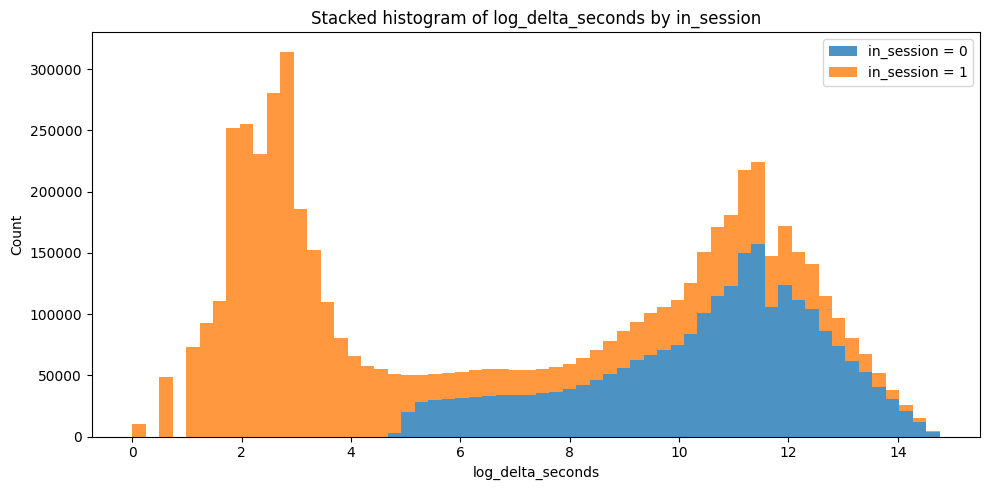

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run the session-labeling cell first.")

plot_df = ratings_session_df.select(["log_delta_seconds", "in_session"]).drop_nulls()

vals_0 = (
    plot_df
    .filter(pl.col("in_session") == 0)
    .select("log_delta_seconds")
    .to_series()
    .to_numpy()
 )
vals_1 = (
    plot_df
    .filter(pl.col("in_session") == 1)
    .select("log_delta_seconds")
    .to_series()
    .to_numpy()
 )

all_vals = np.concatenate([vals_0, vals_1]) if len(vals_0) and len(vals_1) else (vals_0 if len(vals_0) else vals_1)
bins = np.histogram_bin_edges(all_vals, bins=60)

plt.figure(figsize=(10, 5))
plt.hist([vals_0, vals_1], bins=bins, stacked=True, alpha=0.8, label=["in_session = 0", "in_session = 1"])
plt.title("Stacked histogram of log_delta_seconds by in_session")
plt.xlabel("log_delta_seconds")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import polars as pl

if "ratings_session_df" not in globals():
    raise ValueError("`ratings_session_df` not found. Run Cell 6 first.")

base_df = ratings_session_df

if "ratingCreatedAt_ts" in base_df.columns:
    time_col = "ratingCreatedAt_ts"
    base_df = base_df.with_columns(pl.col(time_col).cast(pl.Datetime, strict=False))
elif "ratingCreatedAt" in base_df.columns:
    time_col = "ratingCreatedAt"
    base_df = base_df.with_columns(pl.col(time_col).cast(pl.Datetime, strict=False))
else:
    raise ValueError("Need either `ratingCreatedAt_ts` or `ratingCreatedAt` to order events chronologically.")

if "in_session" not in base_df.columns:
    raise ValueError("`in_session` column not found in dataset.")

session_labeled_df = (
    base_df
    .sort(["raterParticipantId", time_col])
    .with_columns(
        pl.col("in_session").cast(pl.Int8).alias("in_session")
    )
    .with_columns(
        (
            (pl.col("in_session") == 1)
            & (pl.col("in_session").shift(1).over("raterParticipantId").fill_null(0) == 0)
        )
        .cast(pl.Int32)
        .alias("session_start")
    )
    .with_columns(
        pl.col("session_start")
        .cum_sum()
        .over("raterParticipantId")
        .alias("user_session_id")
    )
    .with_columns(
        pl.when(pl.col("in_session") == 1)
        .then(pl.col("user_session_id"))
        .otherwise(None)
        .alias("user_session_id")
    )
    .drop("session_start")
)

session_labeled_df.select(
    "raterParticipantId",
    time_col,
    "in_session",
    "user_session_id",
).head(30)

raterParticipantId,ratingCreatedAt_ts,in_session,user_session_id
str,datetime[μs],i8,i32
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-01-28 20:47:22.321,0,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-01-31 17:21:23.365,0,null
"""00002C7FD6E0080A69D0AB879C3D9B…",2026-02-02 22:44:01.605,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-18 15:41:27.835,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-18 15:44:04.360,0,null
…,…,…,…
"""00003D7D222733AE9D37A25B930204…",2026-01-27 20:43:33.059,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-27 22:02:16.493,0,null
"""00003D7D222733AE9D37A25B930204…",2026-01-30 18:16:23.230,0,null


Headline metrics:


metric,value
str,f64
"""n_users""",484059.0
"""n_users_with_sessions""",239788.0
"""share_users_with_sessions""",0.495369
"""total_sessions""",1.213683e6
"""n_singleton_sessions""",640090.0
"""share_singleton_sessions""",0.527395
"""avg_sessions_per_user""",2.507304
"""median_sessions_per_user""",0.0
"""avg_session_length_events""",2.111275


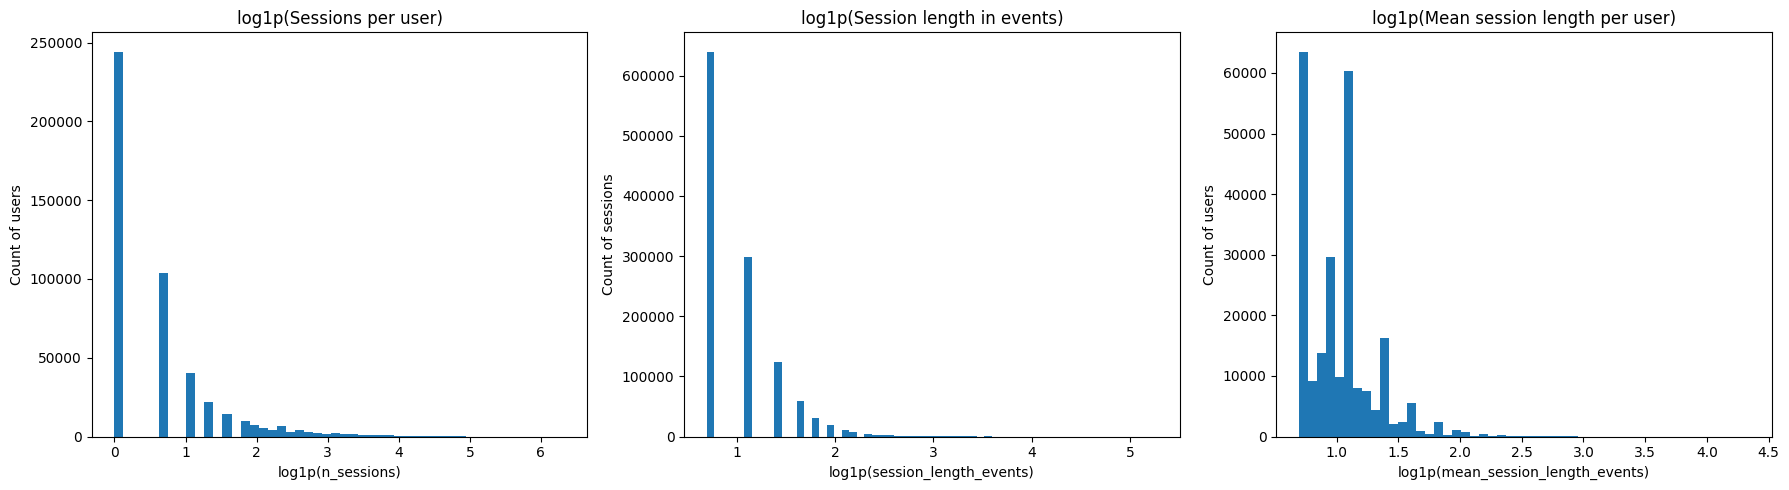

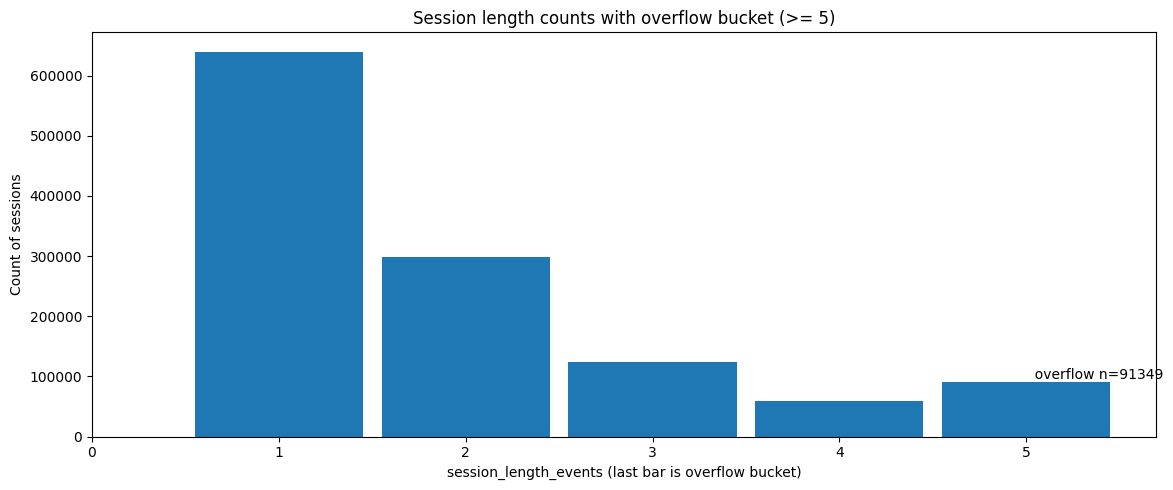

In [23]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

if "user_session_id" not in session_labeled_df.columns:
    raise ValueError("`user_session_id` not found in `session_labeled_df`.")

# Detect which timestamp column exists
if "ratingCreatedAt_ts" in session_labeled_df.columns:
    time_col = "ratingCreatedAt_ts"
elif "ratingCreatedAt" in session_labeled_df.columns:
    time_col = "ratingCreatedAt"
else:
    time_col = None

# -------- Session-level table --------
session_events_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

session_level_df = (
    session_events_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("session_length_events"),
        pl.col("log_delta_seconds").mean().alias("avg_log_delta_seconds_in_session"),
        pl.col("log_delta_seconds").median().alias("median_log_delta_seconds_in_session"),
        *( [
            pl.col(time_col).min().alias("session_start_ts"),
            pl.col(time_col).max().alias("session_end_ts"),
            (
                (pl.col(time_col).max().cast(pl.Int64) - pl.col(time_col).min().cast(pl.Int64))
                / 1_000_000
            ).alias("session_duration_seconds"),
        ] if time_col is not None else [] )
    )
    .sort(["raterParticipantId", "user_session_id"])
)

# -------- User-level summary --------
user_level_df = (
    session_labeled_df
    .group_by("raterParticipantId")
    .agg(
        pl.len().alias("n_total_events"),
        pl.col("in_session").sum().alias("n_in_session_events"),
        pl.col("user_session_id").drop_nulls().n_unique().alias("n_sessions"),
    )
    .with_columns(
        (pl.col("n_in_session_events") / pl.col("n_total_events")).alias("share_events_in_session"),
        pl.when(pl.col("n_sessions") > 0)
        .then(pl.col("n_in_session_events") / pl.col("n_sessions"))
        .otherwise(None)
        .alias("avg_session_length_events_per_user"),
    )
    .sort("n_sessions", descending=True)
)

# Enrich users with mean session length from session-level table
user_session_length_df = (
    session_level_df
    .group_by("raterParticipantId")
    .agg(
        pl.col("session_length_events").mean().alias("mean_session_length_events"),
        pl.col("session_length_events").median().alias("median_session_length_events"),
    )
)

user_level_df = user_level_df.join(user_session_length_df, on="raterParticipantId", how="left")

# -------- Headline metrics --------
n_users = user_level_df.height
n_users_with_sessions = user_level_df.filter(pl.col("n_sessions") > 0).height
total_sessions = session_level_df.height
n_singleton_sessions = session_level_df.filter(pl.col("session_length_events") == 1).height
share_singleton_sessions = (n_singleton_sessions / total_sessions) if total_sessions else 0.0
avg_sessions_per_user = user_level_df.select(pl.col("n_sessions").mean()).item()
median_sessions_per_user = user_level_df.select(pl.col("n_sessions").median()).item()
avg_session_length = session_level_df.select(pl.col("session_length_events").mean()).item() if total_sessions else None
median_session_length = session_level_df.select(pl.col("session_length_events").median()).item() if total_sessions else None

summary_metrics_df = pl.DataFrame(
    {
        "metric": [
            "n_users",
            "n_users_with_sessions",
            "share_users_with_sessions",
            "total_sessions",
            "n_singleton_sessions",
            "share_singleton_sessions",
            "avg_sessions_per_user",
            "median_sessions_per_user",
            "avg_session_length_events",
            "median_session_length_events",
        ],
        "value": [
            float(n_users),
            float(n_users_with_sessions),
            (n_users_with_sessions / n_users) if n_users else 0.0,
            float(total_sessions),
            float(n_singleton_sessions),
            float(share_singleton_sessions),
            float(avg_sessions_per_user) if avg_sessions_per_user is not None else 0.0,
            float(median_sessions_per_user) if median_sessions_per_user is not None else 0.0,
            float(avg_session_length) if avg_session_length is not None else 0.0,
            float(median_session_length) if median_session_length is not None else 0.0,
        ],
    }
)

print("Headline metrics:")
display(summary_metrics_df)

# -------- Graphs (log1p-transformed to reduce tail dominance) --------
sessions_per_user = user_level_df["n_sessions"].to_numpy()
session_lengths = session_level_df["session_length_events"].to_numpy() if total_sessions else np.array([])
mean_session_len_per_user = (
    user_level_df
    .select(pl.col("mean_session_length_events").drop_nulls())
    .to_series()
    .to_numpy()
)

log_sessions_per_user = np.log1p(sessions_per_user)
log_session_lengths = np.log1p(session_lengths) if len(session_lengths) > 0 else np.array([])
log_mean_session_len_per_user = np.log1p(mean_session_len_per_user) if len(mean_session_len_per_user) > 0 else np.array([])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(log_sessions_per_user, bins=50)
axes[0].set_title("log1p(Sessions per user)")
axes[0].set_xlabel("log1p(n_sessions)")
axes[0].set_ylabel("Count of users")

if len(log_session_lengths) > 0:
    axes[1].hist(log_session_lengths, bins=60)
else:
    axes[1].text(0.5, 0.5, "No sessions found", ha="center", va="center")
axes[1].set_title("log1p(Session length in events)")
axes[1].set_xlabel("log1p(session_length_events)")
axes[1].set_ylabel("Count of sessions")

if len(log_mean_session_len_per_user) > 0:
    axes[2].hist(log_mean_session_len_per_user, bins=50)
else:
    axes[2].text(0.5, 0.5, "No users with sessions", ha="center", va="center")
axes[2].set_title("log1p(Mean session length per user)")
axes[2].set_xlabel("log1p(mean_session_length_events)")
axes[2].set_ylabel("Count of users")

plt.tight_layout()
plt.show()

# -------- Additional clearer session-length count view --------
# Bucket very large session lengths into an overflow bucket so counts are easier to read.
if len(session_lengths) > 0:
    overflow_threshold = int(np.quantile(session_lengths, 0.95))
    overflow_threshold = max(overflow_threshold, 1)

    length_count_plot_df = (
        pl.DataFrame({"session_length_events": session_lengths})
        .with_columns(
            pl.when(pl.col("session_length_events") >= overflow_threshold)
            .then(pl.lit(overflow_threshold))
            .otherwise(pl.col("session_length_events"))
            .alias("length_bucket")
        )
        .group_by("length_bucket")
        .agg(pl.len().alias("n_sessions"))
        .sort("length_bucket")
    )

    x_vals = length_count_plot_df["length_bucket"].to_numpy()
    y_vals = length_count_plot_df["n_sessions"].to_numpy()
    overflow_n = int((session_lengths >= overflow_threshold).sum())

    plt.figure(figsize=(12, 5))
    plt.bar(x_vals, y_vals, width=0.9)
    plt.title(f"Session length counts with overflow bucket (>= {overflow_threshold})")
    plt.xlabel("session_length_events (last bar is overflow bucket)")
    plt.ylabel("Count of sessions")

    tick_step = max(1, int(overflow_threshold / 20))
    plt.xticks(np.arange(0, overflow_threshold + 1, tick_step))

    if overflow_n > 0:
        plt.text(
            overflow_threshold,
            y_vals[-1],
            f"  overflow n={overflow_n}",
            va="bottom",
            ha="left",
        )

    plt.tight_layout()
    plt.show()

Dirichlet interest summary:


metric,value
str,f64
"""n_sessions""",1.213683e6
"""n_sessions_with_interest""",517616.0
"""prop_sessions_with_interest""",0.426484
"""overall_prop_interest_ratings""",0.60901
"""avg_prop_interest_ratings_per_…",0.402122
"""median_prop_interest_ratings_p…",0.0
"""avg_interest_ratings_per_sessi…",1.285788
"""avg_ratings_per_session""",2.111275



Session-level interest quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.0,0.0,0.0,1.0,1.0


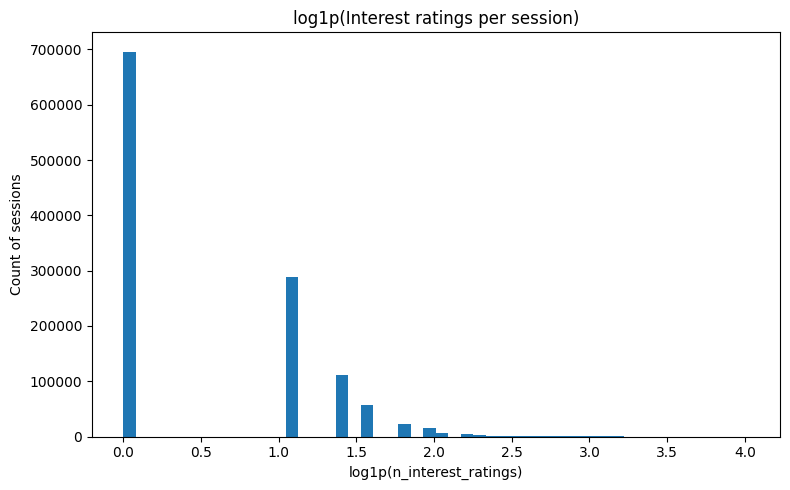


Preview of dirichlet_labeled_df:


raterParticipantId,user_session_id,ratedOnTweetId,in_session,c_post,posterior_mean,interest
str,i32,i64,i8,u32,f64,i8
"""00002C7FD6E0080A69D0AB879C3D9B…",null,2016246745739546987,0,null,null,0
"""00002C7FD6E0080A69D0AB879C3D9B…",null,2017578816177111423,0,null,null,0
"""00002C7FD6E0080A69D0AB879C3D9B…",null,2018387895459983768,0,null,null,0
"""00003D7D222733AE9D37A25B930204…",null,2012586343008755726,0,null,null,0
"""00003D7D222733AE9D37A25B930204…",null,2012586343008755726,0,null,null,0
…,…,…,…,…,…,…
"""00003D7D222733AE9D37A25B930204…",null,2015189340234645945,0,null,null,0
"""00003D7D222733AE9D37A25B930204…",null,2015464613547049370,0,null,null,0
"""00003D7D222733AE9D37A25B930204…",3,2015464613547049370,1,1,1.0,0


In [19]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

required_cols = ["raterParticipantId", "user_session_id", "ratedOnTweetId", "in_session"]
missing_cols = [c for c in required_cols if c not in session_labeled_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

alpha = 1.0

# Use only rows that are in a valid session for posterior calculation
session_rows_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

# c_post: per user-session-post rating counts
post_counts_df = (
    session_rows_df
    .group_by(["raterParticipantId", "user_session_id", "ratedOnTweetId"])
.agg(
        pl.len().alias("c_post")
    )
)

# Session totals needed for Dirichlet posterior mean
session_totals_df = (
    post_counts_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.col("c_post").sum().alias("c_session"),
        pl.len().alias("k_posts"),
    )
)

# Posterior mean under symmetric Dirichlet(alpha=1)
post_posterior_df = (
    post_counts_df
    .join(session_totals_df, on=["raterParticipantId", "user_session_id"], how="left")
    .with_columns(
        ((pl.col("c_post") + alpha) / (pl.col("c_session") + alpha * pl.col("k_posts"))).alias("posterior_mean")
    )
)

# MAP post(s) within session with c_post >= 2
max_count_df = (
    post_posterior_df
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.col("c_post").max().alias("max_c_post")
    )
)

interest_posts_df = (
    post_posterior_df
    .join(max_count_df, on=["raterParticipantId", "user_session_id"], how="left")
    .filter(
        (pl.col("c_post") == pl.col("max_c_post"))
        & (pl.col("c_post") >= 2)
    )
    .select([
        "raterParticipantId",
        "user_session_id",
        "ratedOnTweetId",
        "c_post",
        "posterior_mean",
    ])
    .with_columns(pl.lit(1).cast(pl.Int8).alias("interest"))
)

# Attach posterior/count info and binary interest label back to row-level data
dirichlet_labeled_df = (
    session_labeled_df
    .join(
        post_posterior_df.select([
            "raterParticipantId",
            "user_session_id",
            "ratedOnTweetId",
            "c_post",
            "posterior_mean",
        ]),
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .join(
        interest_posts_df.select(["raterParticipantId", "user_session_id", "ratedOnTweetId", "interest"]),
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("user_session_id").is_null())
        .then(0)
        .otherwise(pl.col("interest").fill_null(0))
        .cast(pl.Int8)
        .alias("interest")
    )
)

# Session-level stats for interest
session_interest_df = (
    dirichlet_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("n_ratings_in_session"),
        pl.col("interest").sum().alias("n_interest_ratings"),
    )
    .with_columns(
        (pl.col("n_interest_ratings") > 0).cast(pl.Int8).alias("session_has_interest"),
        (pl.col("n_interest_ratings") / pl.col("n_ratings_in_session")).alias("prop_interest_ratings"),
    )
)

n_sessions = session_interest_df.height
n_sessions_with_interest = session_interest_df.filter(pl.col("session_has_interest") == 1).height
prop_sessions_with_interest = (n_sessions_with_interest / n_sessions) if n_sessions else 0.0

overall_prop_interest_ratings = (
    dirichlet_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .select(pl.col("interest").mean())
    .item()
    if n_sessions else 0.0
)

avg_prop_interest_ratings_per_session = session_interest_df.select(pl.col("prop_interest_ratings").mean()).item() if n_sessions else 0.0
median_prop_interest_ratings_per_session = session_interest_df.select(pl.col("prop_interest_ratings").median()).item() if n_sessions else 0.0
avg_interest_ratings_per_session = session_interest_df.select(pl.col("n_interest_ratings").mean()).item() if n_sessions else 0.0
avg_ratings_per_session = session_interest_df.select(pl.col("n_ratings_in_session").mean()).item() if n_sessions else 0.0

summary_interest_df = pl.DataFrame(
    {
        "metric": [
            "n_sessions",
            "n_sessions_with_interest",
            "prop_sessions_with_interest",
            "overall_prop_interest_ratings",
            "avg_prop_interest_ratings_per_session",
            "median_prop_interest_ratings_per_session",
            "avg_interest_ratings_per_session",
            "avg_ratings_per_session",
        ],
        "value": [
            float(n_sessions),
            float(n_sessions_with_interest),
            float(prop_sessions_with_interest),
            float(overall_prop_interest_ratings) if overall_prop_interest_ratings is not None else 0.0,
            float(avg_prop_interest_ratings_per_session) if avg_prop_interest_ratings_per_session is not None else 0.0,
            float(median_prop_interest_ratings_per_session) if median_prop_interest_ratings_per_session is not None else 0.0,
            float(avg_interest_ratings_per_session) if avg_interest_ratings_per_session is not None else 0.0,
            float(avg_ratings_per_session) if avg_ratings_per_session is not None else 0.0,
        ],
    }
)

print("Dirichlet interest summary:")
display(summary_interest_df)

print("\nSession-level interest quantiles:")
display(
    session_interest_df.select(
        pl.col("prop_interest_ratings").quantile(0.10).alias("p10"),
        pl.col("prop_interest_ratings").quantile(0.25).alias("p25"),
        pl.col("prop_interest_ratings").quantile(0.50).alias("p50"),
        pl.col("prop_interest_ratings").quantile(0.75).alias("p75"),
        pl.col("prop_interest_ratings").quantile(0.90).alias("p90"),
    )
)

# Graph: logged interest ratings per session
interest_counts = session_interest_df["n_interest_ratings"].to_numpy() if n_sessions else np.array([])
log_interest_counts = np.log1p(interest_counts) if len(interest_counts) > 0 else np.array([])

plt.figure(figsize=(8, 5))
if len(log_interest_counts) > 0:
    plt.hist(log_interest_counts, bins=50)
else:
    plt.text(0.5, 0.5, "No sessions found", ha="center", va="center")
plt.title("log1p(Interest ratings per session)")
plt.xlabel("log1p(n_interest_ratings)")
plt.ylabel("Count of sessions")
plt.tight_layout()
plt.show()

print("\nPreview of dirichlet_labeled_df:")
display(
    dirichlet_labeled_df.select([
        "raterParticipantId",
        "user_session_id",
        "ratedOnTweetId",
        "in_session",
        "c_post",
        "posterior_mean",
        "interest",
    ]).head(20)
)

In [21]:
import polars as pl

if "session_labeled_df" not in globals():
    raise ValueError("`session_labeled_df` not found. Run Cell 10 first.")

required_cols = ["raterParticipantId", "user_session_id", "ratedOnTweetId", "in_session"]
missing_cols = [c for c in required_cols if c not in session_labeled_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Baseline: repeated rating of same tweet within (user, session) => interest
session_rows_df = session_labeled_df.filter(pl.col("user_session_id").is_not_null())

post_counts_df = (
    session_rows_df
    .group_by(["raterParticipantId", "user_session_id", "ratedOnTweetId"])
.agg(
        pl.len().alias("c_post")
    )
)

baseline_labeled_df = (
    session_labeled_df
    .join(
        post_counts_df,
        on=["raterParticipantId", "user_session_id", "ratedOnTweetId"],
        how="left",
    )
    .with_columns(
        pl.when(pl.col("user_session_id").is_null())
        .then(0)
        .otherwise(pl.when(pl.col("c_post").fill_null(0) >= 2).then(1).otherwise(0))
        .cast(pl.Int8)
        .alias("interest_baseline")
    )
)

# Session-level stats (same structure as Cell 12)
baseline_session_interest_df = (
    baseline_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .group_by(["raterParticipantId", "user_session_id"])
.agg(
        pl.len().alias("n_ratings_in_session"),
        pl.col("interest_baseline").sum().alias("n_interest_ratings"),
    )
    .with_columns(
        (pl.col("n_interest_ratings") > 0).cast(pl.Int8).alias("session_has_interest"),
        (pl.col("n_interest_ratings") / pl.col("n_ratings_in_session")).alias("prop_interest_ratings"),
    )
)

n_sessions = baseline_session_interest_df.height
n_sessions_with_interest = baseline_session_interest_df.filter(pl.col("session_has_interest") == 1).height
prop_sessions_with_interest = (n_sessions_with_interest / n_sessions) if n_sessions else 0.0

overall_prop_interest_ratings = (
    baseline_labeled_df
    .filter(pl.col("user_session_id").is_not_null())
    .select(pl.col("interest_baseline").mean())
    .item()
    if n_sessions else 0.0
)

avg_prop_interest_ratings_per_session = baseline_session_interest_df.select(pl.col("prop_interest_ratings").mean()).item() if n_sessions else 0.0
median_prop_interest_ratings_per_session = baseline_session_interest_df.select(pl.col("prop_interest_ratings").median()).item() if n_sessions else 0.0
avg_interest_ratings_per_session = baseline_session_interest_df.select(pl.col("n_interest_ratings").mean()).item() if n_sessions else 0.0
avg_ratings_per_session = baseline_session_interest_df.select(pl.col("n_ratings_in_session").mean()).item() if n_sessions else 0.0

baseline_summary_interest_df = pl.DataFrame(
    {
        "metric": [
            "n_sessions",
            "n_sessions_with_interest",
            "prop_sessions_with_interest",
            "overall_prop_interest_ratings",
            "avg_prop_interest_ratings_per_session",
            "median_prop_interest_ratings_per_session",
            "avg_interest_ratings_per_session",
            "avg_ratings_per_session",
        ],
        "value": [
            float(n_sessions),
            float(n_sessions_with_interest),
            float(prop_sessions_with_interest),
            float(overall_prop_interest_ratings) if overall_prop_interest_ratings is not None else 0.0,
            float(avg_prop_interest_ratings_per_session) if avg_prop_interest_ratings_per_session is not None else 0.0,
            float(median_prop_interest_ratings_per_session) if median_prop_interest_ratings_per_session is not None else 0.0,
            float(avg_interest_ratings_per_session) if avg_interest_ratings_per_session is not None else 0.0,
            float(avg_ratings_per_session) if avg_ratings_per_session is not None else 0.0,
        ],
    }
)

print("Baseline interest summary:")
display(baseline_summary_interest_df)

print("\nBaseline session-level interest quantiles:")
display(
    baseline_session_interest_df.select(
        pl.col("prop_interest_ratings").quantile(0.10).alias("p10"),
        pl.col("prop_interest_ratings").quantile(0.25).alias("p25"),
        pl.col("prop_interest_ratings").quantile(0.50).alias("p50"),
        pl.col("prop_interest_ratings").quantile(0.75).alias("p75"),
        pl.col("prop_interest_ratings").quantile(0.90).alias("p90"),
    )
)

print("\nPreview of baseline_labeled_df:")
display(
    baseline_labeled_df.select([
        "raterParticipantId",
        "user_session_id",
        "ratedOnTweetId",
        "in_session",
        "c_post",
        "interest_baseline",
    ]).head(20)
)

Baseline interest summary:


metric,value
str,f64
"""n_sessions""",1.213683e6
"""n_sessions_with_interest""",517616.0
"""prop_sessions_with_interest""",0.426484
"""overall_prop_interest_ratings""",0.643394
"""avg_prop_interest_ratings_per_…",0.409166
"""median_prop_interest_ratings_p…",0.0
"""avg_interest_ratings_per_sessi…",1.358383
"""avg_ratings_per_session""",2.111275



Baseline session-level interest quantiles:


p10,p25,p50,p75,p90
f64,f64,f64,f64,f64
0.0,0.0,0.0,1.0,1.0



Preview of baseline_labeled_df:


raterParticipantId,user_session_id,ratedOnTweetId,in_session,c_post,interest_baseline
str,i32,i64,i8,u32,i8
"""00002C7FD6E0080A69D0AB879C3D9B…",null,2016246745739546987,0,null,0
"""00002C7FD6E0080A69D0AB879C3D9B…",null,2017578816177111423,0,null,0
"""00002C7FD6E0080A69D0AB879C3D9B…",null,2018387895459983768,0,null,0
"""00003D7D222733AE9D37A25B930204…",null,2012586343008755726,0,null,0
"""00003D7D222733AE9D37A25B930204…",null,2012586343008755726,0,null,0
…,…,…,…,…,…
"""00003D7D222733AE9D37A25B930204…",null,2015189340234645945,0,null,0
"""00003D7D222733AE9D37A25B930204…",null,2015464613547049370,0,null,0
"""00003D7D222733AE9D37A25B930204…",3,2015464613547049370,1,1,0
